# Distribución Normal

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

En la vida real, podemos encontrar estos datos en los siguientes casos:
* El IQ de las personas siguen una distribución normal.
* El peso de los bebés recien nacidos.
* Las calificaciones de un grupo.
* El tamaño de pie de una población.
* La presión sanguinea.
* La altura del tallo del maíz.

Estos se ven porque, la mayoría de los casos siempre estarán en zona media, y los casos atipicos serán casos muy pequeños.

### Altura de las Personas

* La altura promedio de las personas, es de 170 cm.
* Su desviación estándar es de 8 cm. (variabilidad entre medidas)
* La mediana = media = moda es el pico de la campana.

### Regla Empírica 68-95-99.7

* Aproximadamente el ***68%*** de los datos cae dentro de 1 desviación estándar (σ) de la media (μ), es decir, entre μ − σ y μ + σ.
* Aproximadamente el ***95%*** de los datos cae dentro de 2 desviaciones estándar, es decir, entre μ − 2σ y μ + 2σ.
* Aproximadamente el ***99.7%*** de los datos cae dentro de 3 desviaciones estándar, es decir, entre μ − 3σ y μ + 3σ.

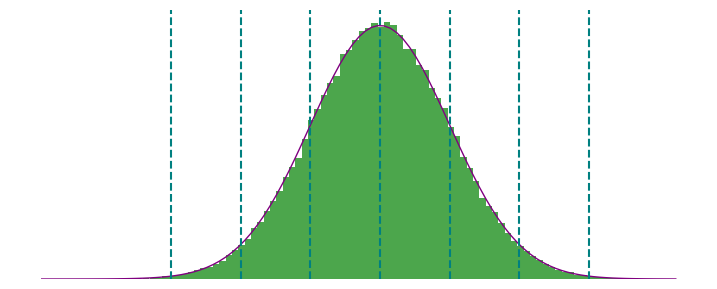

Rangos de referencia:
-6.30 - 9.70 cm	(≈68%)
-14.30 - 17.70 cm	(≈95%)
-22.30 - 25.70 cm	(≈99.7%)

Porcentaje real en los datos:
±1σ: 68.60%
±2σ: 95.44%
±3σ: 99.72%


In [13]:
# Definimos la media y la desviación
mu = 1.70
sigma = 8
n = 100000

# Generamos los valores
np.random.seed(0)
alturas = np.random.normal(loc=mu, scale=sigma, size=n)

# Creación del histograma
plt.figure(figsize=(9, 3.5))
conteo, x, barras = plt.hist(x=alturas, bins=100, density=True, color="green", alpha=0.7)

# Curva de densidad (campana de Gauss)
plt.plot(
    x,
    1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2),
    linewidth=1,
    color="purple"
)

# Líneas en media y desviaciones estándar
sigmas = [
    mu - 3 * sigma, mu - 2 * sigma, mu - sigma,
    mu,
    mu + sigma, mu + 2 * sigma, mu + 3 * sigma
]

for s in sigmas:
    plt.axvline(s, color="teal", linewidth=1.5, linestyle="dashed")

# Estética
plt.yticks([])
plt.xticks([])
plt.box(False)
plt.show()

# Rangos de la regla empírica
print("Rangos de referencia:")
print(f"{mu - sigma:.2f} - {mu + sigma:.2f} cm\t(≈68%)")
print(f"{mu - 2*sigma:.2f} - {mu + 2*sigma:.2f} cm\t(≈95%)")
print(f"{mu - 3*sigma:.2f} - {mu + 3*sigma:.2f} cm\t(≈99.7%)\n")

# Porcentajes reales en los datos simulados
dentro_1_sigma = ((mu - sigma) < alturas) & (alturas < (mu + sigma))
dentro_2_sigma = ((mu - 2*sigma) < alturas) & (alturas < (mu + 2*sigma))
dentro_3_sigma = ((mu - 3*sigma) < alturas) & (alturas < (mu + 3*sigma))

print("Porcentaje real en los datos:")
print(f"±1σ: {dentro_1_sigma.sum() * 100 / n:.2f}%")
print(f"±2σ: {dentro_2_sigma.sum() * 100 / n:.2f}%")
print(f"±3σ: {dentro_3_sigma.sum() * 100 / n:.2f}%")

### Diferentes desviaciones estándar, media constante

Supongamos que tengamos los siguientes datos:
* La alturas de las personas con Media=170 y Desviación estándar 12
* La alturas de las personas con Media=175 y Desviación estándar 12
* La alturas de las personas con Media=180 y Desviación estándar 12

La media hace que que desplaza hacía la izquierda o derecha.

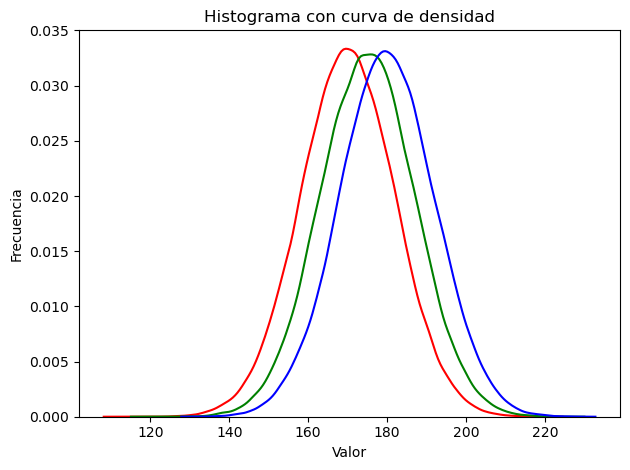

In [16]:
#sns.histplot(datos, bins=20, kde=True, color="lightgreen", edgecolor="black")
np.random.seed(0)
datos1 = np.random.normal(loc=170, scale=12, size=100000)
datos2 = np.random.normal(loc=175, scale=12, size=100000)
datos3 = np.random.normal(loc=180, scale=12, size=100000)

sns.kdeplot(datos1, color="red")
sns.kdeplot(datos2, color="green")
sns.kdeplot(datos3, color="blue")
plt.title("Histograma con curva de densidad")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

Supongamos que tengamos los siguientes datos:
* La alturas de las personas con Media=170 y Desviación estándar 8
* La alturas de las personas con Media=170 y Desviación estándar 12
* La alturas de las personas con Media=170 y Desviación estándar 16

Esto por su lado a larga o achata la campana

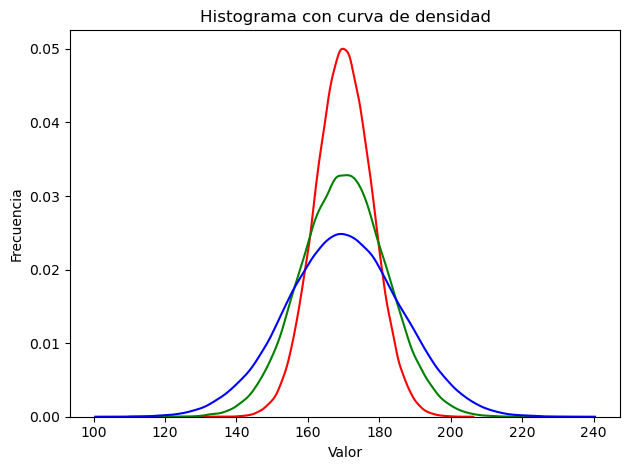

In [18]:
np.random.seed(0)
datos1 = np.random.normal(loc=170, scale=8, size=100000)
datos2 = np.random.normal(loc=170, scale=12, size=100000)
datos3 = np.random.normal(loc=170, scale=16, size=100000)

sns.kdeplot(datos1, color="red")
sns.kdeplot(datos2, color="green")
sns.kdeplot(datos3, color="blue")
plt.title("Histograma con curva de densidad")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

### Función de densidad de probabilidad

* La función de densidad de probabilidad (FDP) o ***"probability density function"*** (PDF) es un concepto fundamental en estadística y probabilidad, especialmente en el contexto de variables aleatorias continuas.
* `np.linspace(start, stop, num)`: genera un array de números igualmente espaciados entre start y stop.
$$
f(x) = \frac{1}{\sigma \sqrt{2\pi}} \cdot e^{-\frac{(x - \mu)^2}{2\sigma^2}}
\begin{cases}
\mu \text{ es la media} \\
\sigma \text{ es la desviación estándar} \\
e \text{ es la constante de Euler}
\end{cases}
$$

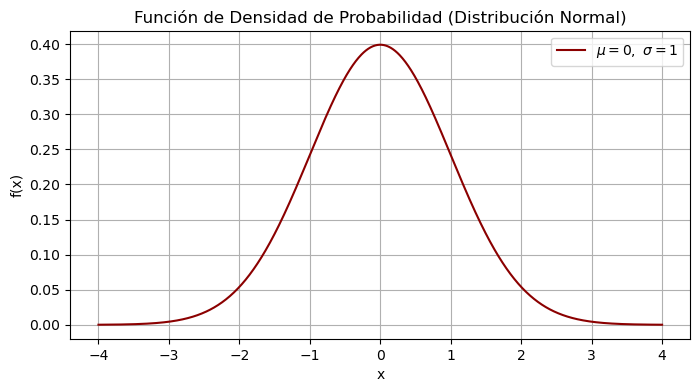

In [4]:
# Parámetros de la distribución
mu = 0
sigma = 1

# Dominio de la función (eje x)
x = np.linspace(-4, 4, 1000)

# Fórmula de la función de densidad normal (FDP)
f_x = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-((x - mu)**2) / (2 * sigma**2))

# Graficar
plt.figure(figsize=(8, 4))

# Pasamos la función para que cada punto sea evaludado
plt.plot(x, f_x, label=fr'$\mu={mu}, \ \sigma={sigma}$', color='darkred')
plt.title('Función de Densidad de Probabilidad (Distribución Normal)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.legend()
plt.show()

### Regla Empirica (Seaborn)

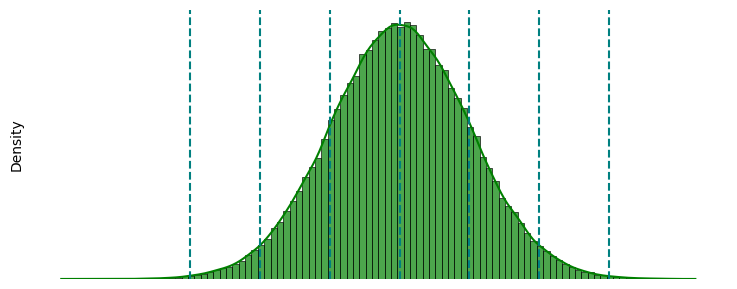

Rangos de referencia:
-6.30 - 9.70 cm	(≈68%)
-14.30 - 17.70 cm	(≈95%)
-22.30 - 25.70 cm	(≈99.7%)

Porcentaje real en los datos:
±1σ: 68.60%
±2σ: 95.44%
±3σ: 99.72%
Porcentaje real en los datos:
±1σ: 68.60%
±2σ: 95.44%
±3σ: 99.72%


In [7]:
# Definimos la media y la desviación
mu = 1.70
sigma = 8
n = 100000

# Generamos los valores
np.random.seed(0)
alturas = np.random.normal(loc=mu, scale=sigma, size=n)

plt.figure(figsize=(9, 3.5))

# Histograma con curva de densidad integrada en seaborn
sns.histplot(alturas, bins=100, kde=True, color="green", stat="density", alpha=0.7)

# Líneas en media y desviaciones estándar
sigmas = [
    mu - 3 * sigma, mu - 2 * sigma, mu - sigma,
    mu,
    mu + sigma, mu + 2 * sigma, mu + 3 * sigma
]

for s in sigmas:
    plt.axvline(s, color="teal", linewidth=1.5, linestyle="dashed")

# Estética
plt.yticks([])
plt.xticks([])
plt.box(False)
plt.show()

# Rangos de la regla empírica
print("Rangos de referencia:")
print(f"{mu - sigma:.2f} - {mu + sigma:.2f} cm\t(≈68%)")
print(f"{mu - 2*sigma:.2f} - {mu + 2*sigma:.2f} cm\t(≈95%)")
print(f"{mu - 3*sigma:.2f} - {mu + 3*sigma:.2f} cm\t(≈99.7%)\n")

# Porcentajes reales en los datos simulados
dentro_1_sigma = ((mu - sigma) < alturas) & (alturas < (mu + sigma))
dentro_2_sigma = ((mu - 2*sigma) < alturas) & (alturas < (mu + 2*sigma))
dentro_3_sigma = ((mu - 3*sigma) < alturas) & (alturas < (mu + 3*sigma))

print("Porcentaje real en los datos:")
print(f"±1σ: {dentro_1_sigma.sum() * 100 / n:.2f}%")
print(f"±2σ: {dentro_2_sigma.sum() * 100 / n:.2f}%")
print(f"±3σ: {dentro_3_sigma.sum() * 100 / n:.2f}%")

print("Porcentaje real en los datos:")
print(f"±1σ: {dentro_1_sigma.sum() * 100 / n:.2f}%")
print(f"±2σ: {dentro_2_sigma.sum() * 100 / n:.2f}%")
print(f"±3σ: {dentro_3_sigma.sum() * 100 / n:.2f}%")